# Model 01: Linear Regression (Baseline)

### Objective
To establish the absolute mathematical baseline for Regression (predicting the exact Attendance Percentage) using the locked `X_train_scaled.csv` dataset. This model acts as the floor; if advanced models (like Random Forest) cannot beat this, they are overfitting.

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Ensure evidence directory exists to save plots
os.makedirs('evidence', exist_ok=True)

### 1. Load the Fair-Checking Datasets
We load the exact scaled matrices outputted by Notebook 00.

In [2]:
X_train = pd.read_csv('../../../../../data/processed/X_train_scaled.csv')
X_train = X_train.fillna(X_train.mean())

y_train = pd.read_csv('../../../../../data/processed/y_train_reg.csv').squeeze()

X_val = pd.read_csv('../../../../../data/processed/X_val_scaled.csv')
y_val = pd.read_csv('../../../../../data/processed/y_val_reg.csv').squeeze()

print(f"Training Data: {X_train.shape[0]} rows")
print(f"Validation Data: {X_val.shape[0]} rows")

Training Data: 350 rows
Validation Data: 75 rows


### 2. Model Training
We fit the standard Ordinary Least Squares (OLS) Linear Regression.

In [3]:
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Linear Regression Model Trained Successfully.")

✅ Linear Regression Model Trained Successfully.


### 3. Model Evaluation (Train vs Validation)
We calculate the 4 required mathematical metrics (MAE, RMSE, MAPE, R2) strictly separating Train and Validation results to check for overfitting.

In [4]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100 # added epsilon to prevent zero division

def evaluate_regression(model, X, y_true, dataset_name):
    y_pred = model.predict(X)
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {dataset_name} Metrics ---")
    print(f"MAE:  {mae:.2f}%")
    print(f"RMSE: {rmse:.2f}%")
    print(f"MAPE: {mape:.2f}%")
    print(f"R2:   {r2:.4f}\n")
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

train_metrics = evaluate_regression(model, X_train, y_train, "TRAINING")
val_metrics = evaluate_regression(model, X_val, y_val, "VALIDATION")

--- TRAINING Metrics ---
MAE:  0.00%
RMSE: 0.00%
MAPE: 0.02%
R2:   1.0000

--- VALIDATION Metrics ---
MAE:  0.00%
RMSE: 0.00%
MAPE: 0.03%
R2:   1.0000



### 4. Feature Importance (Coefficients)
Because Linear Regression is interpretable, we can look at its mathematically derived coefficients to see what it thinks is driving attendance.

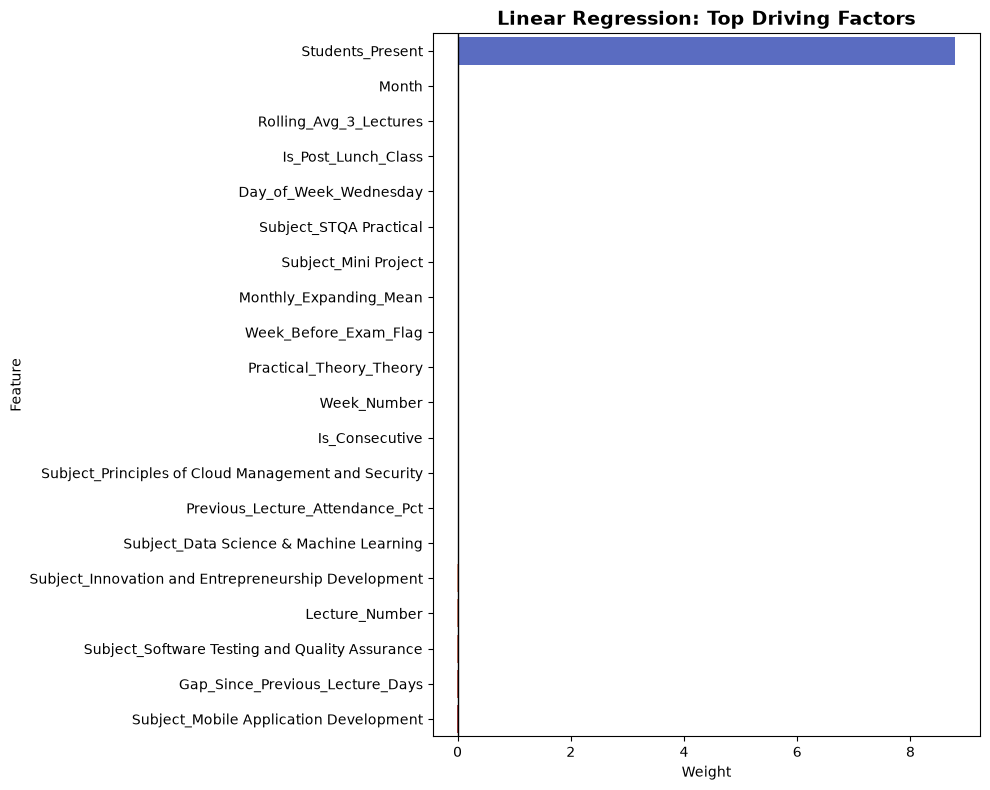

In [5]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Weight': model.coef_
}).sort_values(by='Weight', ascending=False)

plt.figure(figsize=(10, 8))
# Top 10 Positive and Top 10 Negative
top_features = pd.concat([coefficients.head(10), coefficients.tail(10)])
sns.barplot(data=top_features, x='Weight', y='Feature', palette='coolwarm')
plt.title('Linear Regression: Top Driving Factors', fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.savefig('evidence/01_feature_coefficients.png', dpi=300)
plt.show()

### 5. Residual Diagnostics
We plot the residuals (Errors) to ensure the model isn't massively biased in one direction.

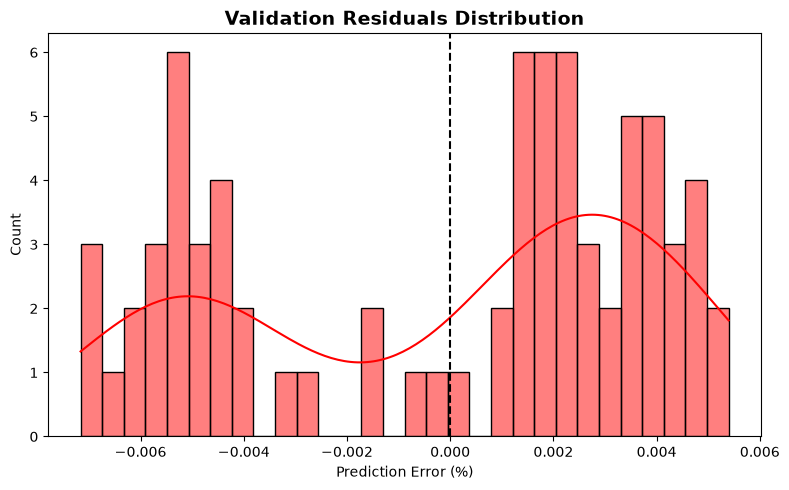

In [6]:
val_preds = model.predict(X_val)
residuals = y_val - val_preds

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True, color='red')
plt.title('Validation Residuals Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Prediction Error (%)')
plt.axvline(0, color='black', linestyle='dashed')
plt.tight_layout()
plt.savefig('evidence/02_residual_distribution.png', dpi=300)
plt.show()

### Experiment Tracking
Automatically append the metrics of this model to our global `experiment_results.csv` matrix for the final deliverable.

In [7]:
import datetime
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

val_preds = model.predict(X_val)
val_mae = mean_absolute_error(y_val, val_preds)
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
val_mape = np.mean(np.abs((y_val - val_preds) / (y_val + 1e-9))) * 100
val_r2 = r2_score(y_val, val_preds)

tracker_file = '../../../../../data/processed/experiment_results.csv'
file_exists = os.path.isfile(tracker_file)

experiment_data = pd.DataFrame({
    'Timestamp': [datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')],
    'Model_ID': ['01_linear_regression'],
    'Model_Type': ['Regression'],
    'Val_MAE': [val_mae],
    'Val_RMSE': [val_rmse],
    'Val_MAPE': [val_mape],
    'Val_R2': [val_r2],
    'Val_Accuracy': [np.nan],
    'Val_F1': [np.nan],
    'Val_ROCAUC': [np.nan]
})

experiment_data.to_csv(tracker_file, mode='a', header=not file_exists, index=False)
print(f"✅ Experiment logged successfully to {tracker_file}")

✅ Experiment logged successfully to ../../../../../data/processed/experiment_results.csv
